###

### **Facebook Post Generation Implemented by Iterative workflow**

In [36]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage
from operator import add
from pydantic import BaseModel, Field

In [4]:
os.environ['GOOGLE_API_KEY'] = os.getenv("GOOGLE_API_KEY")
model = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash"
)
print(f"[INFO] Model : {model.model} Loaded Successfully!")

[INFO] Model : gemini-3.6-flash Loaded Successfully!


### **Creating PostState**

In [51]:
class PostState(TypedDict):
    topic : str
    post : str
    evaluation: Literal["approved","needs_improvement"]
    feedback : str
    iteration : int = 0
    max_iteration : int

    post_history: Annotated[List[str], add]
    feedback_history: Annotated[List[str], add]
    

### **Creating Post Evaluation Model**


In [8]:
class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final Evaluation Result.")
    feedback: str = Field(..., description="Feedback for the facebook post.")

evaluation_model = model.with_structured_output(PostEvaluation)

### **Creating a PostGenerator Model**

In [14]:
class PostGenerator(BaseModel):
    post : str = Field(..., description="Write a facebook post on the given topic")

post_model = model.with_structured_output(PostGenerator)

### **Creating the Optimizer Model**

In [16]:
class PostOptimizer(BaseModel):
    post : str = Field(..., description="Optimize the given Facebook Post")

optimizer_model = model.with_structured_output(PostOptimizer)

### **Node 1 : Generation Node**

In [18]:
def post_generation(state: PostState):
    topic = state['topic']

    prompt = [
        SystemMessage(content="You are a funny and clever facebook post influencer."),
        HumanMessage(content= f"""Write a short, original, and hilarious Facebook post on the topic: "{topic}".\n
        Rules:
        - Do NOT use question-answer format.
        - Max 200 words.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """
        ) 
    ]

    post = post_model.invoke(prompt).post

    return {
        "post" : post,
        "post_history" : [post]
    }

### **Node 2 : Evaluate Post Node**

In [20]:
def evaluate_post(state: PostState):
    post = state['post']

    prompt = [
        SystemMessage(content="'You are a ruthless, no-laugh-given Facebook critic. You evaluate posts based on humor, originality, virality, and post format."),
        HumanMessage(content= f"""Evaluate the following Facebook post:

Post: "{post}"

Use the criteria below to evaluate the post:

1. Originality Is this fresh, or have you seen it a hundred times before?
2. Humor Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness Is it short, sharp, and scroll-stopping?
4. Virality Potential Would people share, react, or comment on it?
5. Format Is it a well-formed Facebook post (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 500 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle universe" or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
        """
        ) 
    ]

    post = evaluation_model.invoke(prompt)

    return {
        "evaluation" : post.evaluation,
        "feedback" : post.feedback,
        "feedback_history" : [post.feedback]
    }

### **Node 3 : Optimizer Node**

In [21]:
def optimize_post(state: PostState):
    prompt = [
    SystemMessage(content="You punch up Facebook posts for virality and humor based on given feedback."),
    HumanMessage(content=f"""
    Improve the Facebook post based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Post:
    {state['post']}

    Re-write it as a short, viral-worthy Facebook post. Avoid Q&A style and stay under 500 characters.
    """)
    ]

    post = optimizer_model.invoke(prompt).post
    iteration = state['iteration'] + 1
    return {
        "post" : post,
        "iteration" : iteration,
        "post_history": post
    }


### **Creating the evalute condition**

In [ ]:
def evaluation_condition_check(state: PostState):
    evaluation = state['evaluation'].lower()

    if evaluation == "needs_improvement" and state['iteration'] <= state['max_iteration']:
        return "needs_improvement"
    else:
        return "approved"

### **Creating the StateGraph**

In [58]:
graph = StateGraph(PostState)

graph.add_node("post_generation", post_generation)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("optimize_post", optimize_post)

graph.add_edge(START, "post_generation")
graph.add_edge("post_generation", "evaluate_post")
graph.add_conditional_edges("evaluate_post", evaluation_condition_check, {"approved" : END, "needs_improvement":"optimize_post"})
graph.add_edge("optimize_post", "evaluate_post")


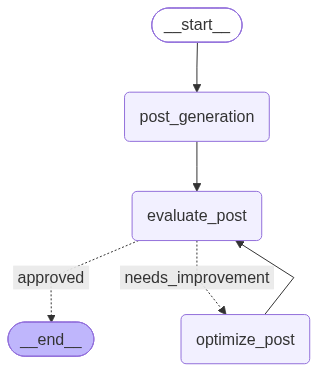

In [59]:
workflow = graph.compile()
workflow

### **Invoking the Workflow**

In [60]:
response = workflow.invoke({
    "topic" : "VLM",
    "iteration" : 1,
    "max_iteration" : 3
})

In [61]:
response

{'topic': 'VLM',
 'post': 'Humanity spent billions of dollars developing Vision Language Models just so an AI can look at a photo of my messy room and describe it as a crime scene of bad decisions. We literally gave computers eyes and the very first thing they decided to do was roast our life choices in 4K resolution. I showed it a picture of my sleeping dog yesterday and it asked me why my loaf of sourdough has legs.',
 'evaluation': 'approved',
 'feedback': 'This post hits the sweet spot for modern tech satire with sharp observational humor and strong virality potential, comfortably avoiding traditional setup-punchline formatting and staying well under the character limit. The progression from high-level absurdity to a specific, vivid punchline about the sourdough dog keeps it punchy and highly shareable, though the transition between the general AI commentary and the personal anecdote feels slightly abrupt.',
 'iteration': 1,
 'max_iteration': 3,
 'post_history': ['Humanity spent bi